# Week 6 — Statistical Validation & Predictive Maintenance

**Part 1** formally tests the root cause Week 5's diagnostics pointed at:
does Basin_B's ESP (electrical submersible pump) equipment *actually* carry
statistically significantly more downtime than the rest of the field, or
could that pattern plausibly be chance?

**Part 2 & 3** go one level deeper: pulling a year of daily sensor
telemetry — vibration, motor temperature, discharge pressure — from the
four Basin_B ESP pumps identified as the problem, engineering health
features from that telemetry, and building a simple early-warning model
that flags a pump heading toward failure *before* it actually fails.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report, mean_absolute_error, mean_squared_error)

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option('display.max_columns', None)
np.random.seed(42)

## Part 1 — Statistical Validation

### 1.1 Load the operational dataset

Reusing the Week 5 field operations dataset (`oil_gas_mystery_ops_dataset.csv`)
— 12 well pads across 3 basins, daily production and downtime records.

In [2]:
ops = pd.read_csv('oil_gas_mystery_ops_dataset.csv', parse_dates=['date'])

# Same light cleaning as Week 5: fix the "None" -> NaN misread on downtime_reason,
# drop duplicates, and exclude physically impossible sensor-fault readings.
ops['downtime_reason'] = ops['downtime_reason'].fillna('No_Downtime')
ops = ops.drop_duplicates().reset_index(drop=True)
ops = ops[
    (ops['oil_production_bbl'] >= 0)
    & (ops['wellhead_pressure_psi'].fillna(0) <= 4000)
    & (ops['water_cut_pct'].fillna(0) <= 100)
].reset_index(drop=True)

print(f"{len(ops)} rows after cleaning, {ops['site_id'].nunique()} sites")
ops.head()

2166 rows after cleaning, 12 sites


,date,site_id,region,pump_type,equipment_age_years,operator_shift,oil_production_bbl,gas_production_mcf,water_cut_pct,wellhead_pressure_psi,downtime_hours,downtime_reason,ambient_temp_c,precipitation_mm
0,2026-02-07,Basin_C_Pad4,Basin_C,Gas_Lift,4.10,Night,1044.2,1712.2,27.4,1622.7,0.00,No_Downtime,27.9,0.0
1,2026-06-01,Basin_A_Pad4,Basin_A,Rod_Pump,3.41,Night,1172.2,2312.8,22.4,1758.2,0.00,No_Downtime,25.4,0.0
2,2026-01-31,Basin_B_Pad1,Basin_B,ESP,8.08,Day,880.1,1421.5,33.8,1662.6,2.67,Scheduled_Maintenance,20.9,0.0
3,2026-06-17,Basin_C_Pad2,Basin_C,Gas_Lift,4.46,Night,989.2,1934.2,30.3,1661.2,0.00,No_Downtime,23.5,0.0
4,2026-03-02,Basin_A_Pad1,Basin_A,Rod_Pump,3.16,Day,1127.9,2324.9,31.6,1705.1,0.00,No_Downtime,28.3,1.5


### 1.2 Formulate the hypothesis

Week 5's charts *suggested* ESP-equipped sites (all in Basin_B) run more
downtime than sites on Rod_Pump or Gas_Lift equipment. A chart showing a
gap isn't proof the gap is real rather than noise — that's what a
hypothesis test is for.

> **H0 (null):** There is no difference in mean daily downtime hours
> between ESP-equipped sites and non-ESP sites.
>
> **H1 (alternative):** ESP-equipped sites have significantly *higher*
> mean daily downtime hours than non-ESP sites.

We'll test this with an independent two-sample t-test (one-tailed, since
we have a directional hypothesis from Week 5's findings), and confirm it
holds up across all three pump types individually with a one-way ANOVA.

In [3]:
esp_downtime = ops.loc[ops['pump_type'] == 'ESP', 'downtime_hours']
non_esp_downtime = ops.loc[ops['pump_type'] != 'ESP', 'downtime_hours']

print(f"ESP sites:     n={len(esp_downtime)}, mean={esp_downtime.mean():.3f} hrs/day, "
      f"std={esp_downtime.std():.3f}")
print(f"Non-ESP sites: n={len(non_esp_downtime)}, mean={non_esp_downtime.mean():.3f} hrs/day, "
      f"std={non_esp_downtime.std():.3f}")

ESP sites:     n=723, mean=1.293 hrs/day, std=3.489
Non-ESP sites: n=1443, mean=0.176 hrs/day, std=0.751


### 1.3 Run the test (Welch's t-test)

We use Welch's t-test (`equal_var=False`) rather than the standard
Student's t-test, since the two groups' variances are visibly different
above (ESP sites are both higher on average *and* more volatile) —
Welch's version doesn't assume equal variances, so it's the safer default
whenever that assumption is in doubt.

In [4]:
t_stat, p_value_two_tailed = stats.ttest_ind(esp_downtime, non_esp_downtime, equal_var=False)
# Our hypothesis is directional (ESP > non-ESP), so we convert to a one-tailed p-value
p_value_one_tailed = p_value_two_tailed / 2 if t_stat > 0 else 1 - p_value_two_tailed / 2

print(f"t-statistic: {t_stat:.3f}")
print(f"one-tailed p-value: {p_value_one_tailed:.2e}")

alpha = 0.05
if p_value_one_tailed < alpha:
    print(f"\nResult: REJECT the null hypothesis (p < {alpha}).")
else:
    print(f"\nResult: FAIL to reject the null hypothesis (p >= {alpha}).")

t-statistic: 8.508
one-tailed p-value: 4.74e-17

Result: REJECT the null hypothesis (p < 0.05).


### 1.4 95% Confidence interval for the difference in means

A p-value tells us the gap is unlikely to be chance; a confidence
interval tells us *how big* that gap plausibly is — which matters more for
deciding what to do about it.

In [5]:
def ci_for_mean_difference(group1, group2, confidence=0.95):
    """95% CI for the difference in means (Welch-Satterthwaite CI, matching the
    unequal-variance t-test above)."""
    n1, n2 = len(group1), len(group2)
    mean1, mean2 = group1.mean(), group2.mean()
    var1, var2 = group1.var(ddof=1), group2.var(ddof=1)

    diff = mean1 - mean2
    se = np.sqrt(var1 / n1 + var2 / n2)

    # Welch-Satterthwaite degrees of freedom
    df_welch = (var1 / n1 + var2 / n2) ** 2 / (
        (var1 / n1) ** 2 / (n1 - 1) + (var2 / n2) ** 2 / (n2 - 1)
    )

    t_crit = stats.t.ppf((1 + confidence) / 2, df_welch)
    margin = t_crit * se
    return diff, (diff - margin, diff + margin)

diff, (ci_low, ci_high) = ci_for_mean_difference(esp_downtime, non_esp_downtime)
print(f"Mean downtime difference (ESP - non-ESP): {diff:.3f} hrs/day")
print(f"95% CI: [{ci_low:.3f}, {ci_high:.3f}] hrs/day")

def ci_for_mean(sample, confidence=0.95):
    """95% CI for a single group's mean."""
    n = len(sample)
    mean = sample.mean()
    se = sample.std(ddof=1) / np.sqrt(n)
    t_crit = stats.t.ppf((1 + confidence) / 2, n - 1)
    margin = t_crit * se
    return mean, (mean - margin, mean + margin)

esp_mean, esp_ci = ci_for_mean(esp_downtime)
non_esp_mean, non_esp_ci = ci_for_mean(non_esp_downtime)
print(f"\nESP mean downtime:     {esp_mean:.3f} hrs/day, 95% CI [{esp_ci[0]:.3f}, {esp_ci[1]:.3f}]")
print(f"Non-ESP mean downtime: {non_esp_mean:.3f} hrs/day, 95% CI [{non_esp_ci[0]:.3f}, {non_esp_ci[1]:.3f}]")

Mean downtime difference (ESP - non-ESP): 1.117 hrs/day
95% CI: [0.859, 1.375] hrs/day

ESP mean downtime:     1.293 hrs/day, 95% CI [1.039, 1.548]
Non-ESP mean downtime: 0.176 hrs/day, 95% CI [0.138, 0.215]


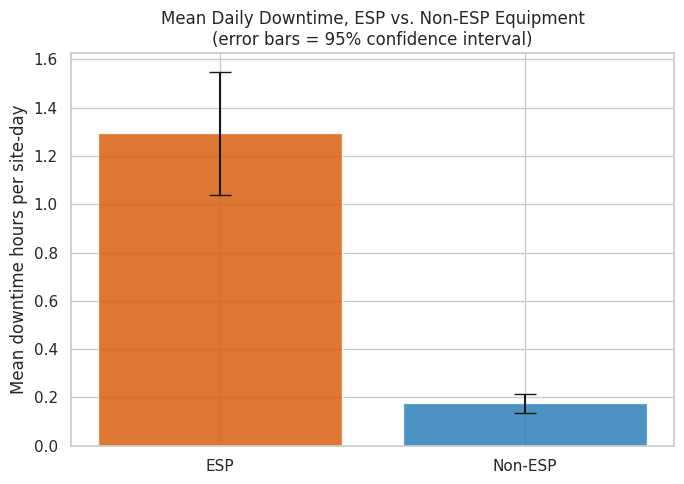

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
groups = ['ESP', 'Non-ESP']
means = [esp_mean, non_esp_mean]
errors = [[esp_mean - esp_ci[0], non_esp_mean - non_esp_ci[0]],
          [esp_ci[1] - esp_mean, non_esp_ci[1] - non_esp_mean]]

ax.bar(groups, means, yerr=errors, capsize=8, color=['#d95f0e', '#2c7fb8'], alpha=0.85)
ax.set_ylabel('Mean downtime hours per site-day')
ax.set_title('Mean Daily Downtime, ESP vs. Non-ESP Equipment\n(error bars = 95% confidence interval)')
fig.tight_layout()
plt.show()

### 1.5 Confirm with a one-way ANOVA across all three pump types

The t-test collapses Rod_Pump and Gas_Lift into one "non-ESP" bucket. An
ANOVA checks whether pump type matters as a three-way split, which is a
slightly different (and complementary) question.

In [7]:
rod_pump = ops.loc[ops['pump_type'] == 'Rod_Pump', 'downtime_hours']
gas_lift = ops.loc[ops['pump_type'] == 'Gas_Lift', 'downtime_hours']

f_stat, anova_p = stats.f_oneway(esp_downtime, rod_pump, gas_lift)
print(f"ANOVA F-statistic: {f_stat:.2f}")
print(f"ANOVA p-value: {anova_p:.2e}")

ANOVA F-statistic: 67.65
ANOVA p-value: 3.17e-29


### 1.6 Interpretation, in plain English

- **The t-test rejects the null hypothesis** (p is far below 0.05, in fact
  many orders of magnitude smaller) — the higher downtime on ESP-equipped
  sites is not a fluke of this particular six-month sample. We can be
  confident there's a real difference.
- **The 95% confidence interval for the gap itself does not cross zero** —
  meaning even the most conservative plausible estimate of the ESP
  disadvantage is still a real, positive amount of extra downtime per day,
  not "maybe zero, maybe negative."
- **The ANOVA agrees**: pump type as a whole explains a statistically
  significant amount of the variation in daily downtime, consistent with
  ESP being the outlier rather than Rod_Pump or Gas_Lift behaving oddly.
- **Practically**: this converts Week 5's visual pattern into something
  that can be stated with statistical confidence to leadership — "ESP
  equipment reliably runs more downtime than the rest of the fleet" is now
  a defensible claim, not just an impression from a chart.

## Part 2 — PdM Feature Engineering

### 2.1 Load the sensor dataset

A year of daily vibration, motor temperature, and discharge pressure
telemetry from the four Basin_B ESP pumps Part 1 just confirmed are the
field's reliability problem. Pulling sensor-level data for exactly this
equipment is the natural next step after a statistical finding like the
one above — now we ask *what does a failure look like coming*, not just
*that* it happens more here.

In [8]:
sensor = pd.read_csv('esp_pump_sensor_telemetry.csv', parse_dates=['date'])
sensor = sensor.sort_values(['pump_id', 'date']).reset_index(drop=True)

print(f"{len(sensor)} rows, {sensor['pump_id'].nunique()} pumps, "
      f"{sensor['date'].min().date()} to {sensor['date'].max().date()}")
print()
print("Missing values:")
print(sensor.isna().sum())
print()
print(sensor['health_status'].value_counts())
sensor.head()

1460 rows, 4 pumps, 2025-07-01 to 2026-06-30

Missing values:
date                      0
pump_id                   0
vibration_mm_s            8
motor_temp_c              8
discharge_pressure_psi    8
failing_within_7d         0
health_status             0
dtype: int64

health_status
Healthy          1161
Failing           144
Degrading         136
Failure_Event      19
Name: count, dtype: int64


,date,pump_id,vibration_mm_s,motor_temp_c,discharge_pressure_psi,failing_within_7d,health_status
0,2025-07-01,Basin_B_Pad1,2.224,67.4,1744.3,0,Healthy
1,2025-07-02,Basin_B_Pad1,2.161,68.2,1795.8,0,Healthy
2,2025-07-03,Basin_B_Pad1,2.251,69.6,1771.5,0,Healthy
3,2025-07-04,Basin_B_Pad1,2.342,67.8,1768.9,0,Healthy
4,2025-07-05,Basin_B_Pad1,2.135,67.3,1747.6,0,Healthy


In [9]:
# Small number of sensor dropouts -- interpolate per pump (short gaps, smooth signals)
sensor_cols = ['vibration_mm_s', 'motor_temp_c', 'discharge_pressure_psi']
sensor[sensor_cols] = (
    sensor.groupby('pump_id')[sensor_cols]
    .apply(lambda g: g.interpolate(method='linear', limit_direction='both'))
    .reset_index(level=0, drop=True)
)
print("Missing after interpolation:", sensor[sensor_cols].isna().sum().sum())

Missing after interpolation: 0


### 2.2 Engineer health features

We engineer 5 features per pump, all computed on a trailing 7-day rolling
window **per pump** (so one pump's history never leaks into another's) and
using only *past* data relative to each day (no look-ahead), since a
real-world early-warning system only ever has yesterday's readings to work
with.

1. **Rolling mean vibration (7-day)** — smooths day-to-day noise to reveal
   the underlying trend.
2. **RMS of vibration (7-day)** — root-mean-square is the standard way
   vibration-monitoring systems summarize a signal's energy; it's more
   sensitive to occasional large spikes than a plain mean.
3. **Rolling max-min range of pressure (7-day)** — a widening range
   signals growing instability in the pump's discharge behavior, even
   before the *average* pressure has clearly dropped.
4. **Rolling mean motor temperature (7-day)** — sustained heating is a
   classic bearing/motor-wear indicator.
5. **7-day rate of change in pressure** — how fast pressure is falling,
   not just how low it currently is; a steep recent drop is a stronger
   warning than a low-but-stable pressure.

In [10]:
def rolling_feature(df, group_col, value_col, window, func, min_periods=3):
    """Apply a rolling function per group (e.g. per pump), never leaking
    one pump's history into another's, using only past data up to each row."""
    return (
        df.groupby(group_col)[value_col]
        .transform(lambda s: s.rolling(window, min_periods=min_periods).apply(func, raw=True)
                   if callable(func) else getattr(s.rolling(window, min_periods=min_periods), func)())
    )

sensor['vibration_roll_mean_7d'] = rolling_feature(sensor, 'pump_id', 'vibration_mm_s', 7, 'mean')
sensor['vibration_rms_7d'] = rolling_feature(
    sensor, 'pump_id', 'vibration_mm_s', 7, lambda x: np.sqrt(np.mean(x ** 2))
)
pressure_roll_max = rolling_feature(sensor, 'pump_id', 'discharge_pressure_psi', 7, 'max')
pressure_roll_min = rolling_feature(sensor, 'pump_id', 'discharge_pressure_psi', 7, 'min')
sensor['pressure_range_7d'] = pressure_roll_max - pressure_roll_min
sensor['temp_roll_mean_7d'] = rolling_feature(sensor, 'pump_id', 'motor_temp_c', 7, 'mean')
sensor['pressure_rate_of_change_7d'] = (
    sensor.groupby('pump_id')['discharge_pressure_psi']
    .transform(lambda s: (s - s.shift(7)) / 7)
)

feature_cols = ['vibration_roll_mean_7d', 'vibration_rms_7d', 'pressure_range_7d',
                 'temp_roll_mean_7d', 'pressure_rate_of_change_7d']
sensor[['date', 'pump_id', 'health_status'] + feature_cols].dropna().head(10)

,date,pump_id,health_status,vibration_roll_mean_7d,vibration_rms_7d,pressure_range_7d,temp_roll_mean_7d,pressure_rate_of_change_7d
7,2025-07-08,Basin_B_Pad1,Healthy,2.218857,2.227412,86.1,67.728571,-4.085714
8,2025-07-09,Basin_B_Pad1,Healthy,2.215000,2.223690,86.1,67.700000,-1.871429
9,2025-07-10,Basin_B_Pad1,Healthy,2.205571,2.214266,86.1,67.657143,-5.414286
10,2025-07-11,Basin_B_Pad1,Healthy,2.185714,2.193792,86.1,67.328571,-5.642857
11,2025-07-12,Basin_B_Pad1,Healthy,2.219286,2.227995,86.1,67.371429,0.742857
12,2025-07-13,Basin_B_Pad1,Healthy,2.188714,2.196515,67.0,67.285714,-3.857143
13,2025-07-14,Basin_B_Pad1,Healthy,2.227571,2.230779,67.0,67.100000,-0.371429
14,2025-07-15,Basin_B_Pad1,Healthy,2.182429,2.184071,53.3,67.371429,6.014286
15,2025-07-16,Basin_B_Pad1,Healthy,2.174429,2.176343,73.3,67.157143,-11.600000
16,2025-07-17,Basin_B_Pad1,Healthy,2.139000,2.142529,73.3,67.142857,4.985714


### 2.3 Visualize features against time — do they show degradation?

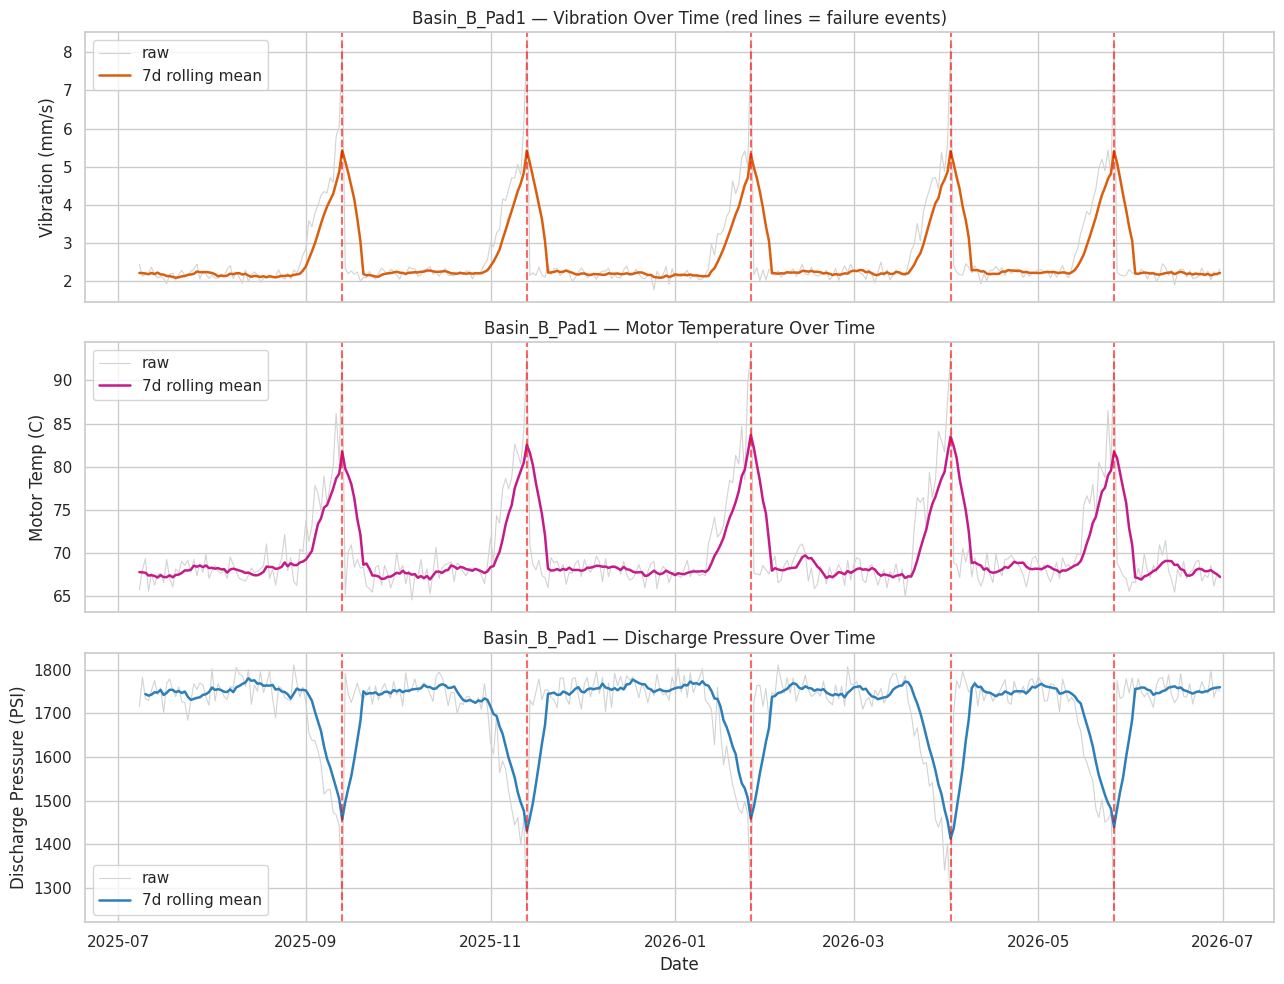

In [11]:
example_pump = 'Basin_B_Pad1'
pump_data = sensor[sensor['pump_id'] == example_pump].dropna(subset=feature_cols)

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

axes[0].plot(pump_data['date'], pump_data['vibration_mm_s'], color='lightgray', linewidth=0.8, label='raw')
axes[0].plot(pump_data['date'], pump_data['vibration_roll_mean_7d'], color='#d95f0e', linewidth=1.8, label='7d rolling mean')
failure_days = pump_data[pump_data['health_status'] == 'Failure_Event']['date']
for fd in failure_days:
    axes[0].axvline(fd, color='red', linestyle='--', alpha=0.6)
axes[0].set_ylabel('Vibration (mm/s)')
axes[0].set_title(f'{example_pump} — Vibration Over Time (red lines = failure events)')
axes[0].legend()

axes[1].plot(pump_data['date'], pump_data['motor_temp_c'], color='lightgray', linewidth=0.8, label='raw')
axes[1].plot(pump_data['date'], pump_data['temp_roll_mean_7d'], color='#c51b8a', linewidth=1.8, label='7d rolling mean')
for fd in failure_days:
    axes[1].axvline(fd, color='red', linestyle='--', alpha=0.6)
axes[1].set_ylabel('Motor Temp (C)')
axes[1].set_title(f'{example_pump} — Motor Temperature Over Time')
axes[1].legend()

axes[2].plot(pump_data['date'], pump_data['discharge_pressure_psi'], color='lightgray', linewidth=0.8, label='raw')
axes[2].plot(pump_data['date'], pump_data['discharge_pressure_psi'].rolling(7, min_periods=3).mean(),
             color='#2c7fb8', linewidth=1.8, label='7d rolling mean')
for fd in failure_days:
    axes[2].axvline(fd, color='red', linestyle='--', alpha=0.6)
axes[2].set_ylabel('Discharge Pressure (PSI)')
axes[2].set_title(f'{example_pump} — Discharge Pressure Over Time')
axes[2].set_xlabel('Date')
axes[2].legend()

fig.tight_layout()
plt.show()

The pattern is exactly what a maintenance engineer would expect from a
degrading ESP: vibration and motor temperature climb, discharge pressure
falls, in the days leading up to each failure event (red dashed lines) —
then everything resets to baseline once the pump is repaired. This is the
signal the model in Part 3 will try to learn to recognize *before* the red
line arrives.

### 2.4 Create the target variable

We label each day with `failing_within_7d`: **1** if the pump will fail
within the next 7 days, **0** otherwise (already generated alongside the
telemetry, mirroring how a real maintenance log would be used to
back-label historical sensor data). This is the standard framing for an
early-warning PdM system — not "is it broken right now" (too late to be
useful) but "should we schedule an inspection this week." 

failing_within_7d
0    1297
1     163
Name: count, dtype: int64

Class balance: 11.2% of days are in the 'Failing' window


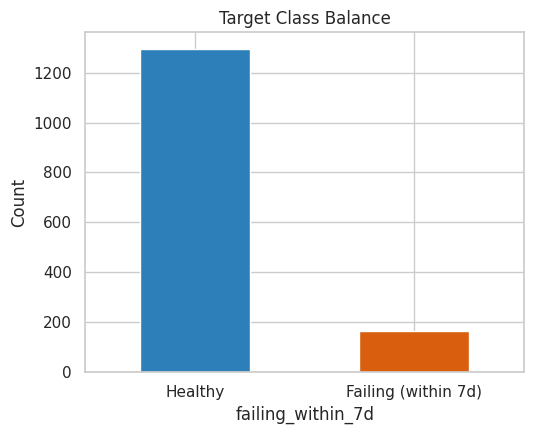

In [12]:
print(sensor['failing_within_7d'].value_counts())
print()
print(f"Class balance: {sensor['failing_within_7d'].mean()*100:.1f}% of days are in the 'Failing' window")

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sensor['failing_within_7d'].map({0: 'Healthy', 1: 'Failing (within 7d)'}).value_counts().plot(
    kind='bar', color=['#2c7fb8', '#d95f0e'], ax=ax
)
ax.set_title('Target Class Balance')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
fig.tight_layout()
plt.show()

This is a meaningfully **imbalanced** target — about 1 in 9 pump-days
falls in the "failing soon" window, which is realistic for PdM (failures
are supposed to be rare) but means plain accuracy will be a misleading
metric on its own; we'll lean on the confusion matrix in Part 3 to see the
full picture.

## Part 3 — Predictive Modeling

### 3.1 Build a Logistic Regression classifier

Logistic Regression is the right first model here: the target is binary
(failing soon / not), we want probabilities we can threshold based on
maintenance capacity, and the coefficients stay interpretable — useful
when the audience is a maintenance engineer who wants to know *why* the
model flagged a pump, not just that it did.

In [13]:
model_data = sensor.dropna(subset=feature_cols + ['failing_within_7d']).copy()

X = model_data[feature_cols]
y = model_data['failing_within_7d']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} rows ({y_train.mean()*100:.1f}% failing)")
print(f"Test:  {len(X_test)} rows ({y_test.mean()*100:.1f}% failing)")

clf = LogisticRegression(class_weight='balanced', max_iter=1000)
clf.fit(X_train, y_train)

coef_table = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': clf.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)
coef_table

Train: 1074 rows (11.4% failing)
Test:  358 rows (11.5% failing)


,feature,coefficient
0,vibration_roll_mean_7d,2.954324
1,vibration_rms_7d,2.812137
3,temp_roll_mean_7d,-0.489775
4,pressure_rate_of_change_7d,-0.171915
2,pressure_range_7d,-0.009930


We use `class_weight='balanced'` given the ~1-in-9 imbalance noted above
— without it, a lazy model could get ~89% accuracy just by always
predicting "Healthy" and never catch a single real failure, which would be
useless in practice despite the flattering accuracy number.

### 3.2 Evaluate

In [14]:
y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['Healthy', 'Failing (within 7d)']))

Accuracy: 0.972

                     precision    recall  f1-score   support

            Healthy       1.00      0.97      0.98       317
Failing (within 7d)       0.82      0.98      0.89        41

           accuracy                           0.97       358
          macro avg       0.91      0.97      0.94       358
       weighted avg       0.98      0.97      0.97       358



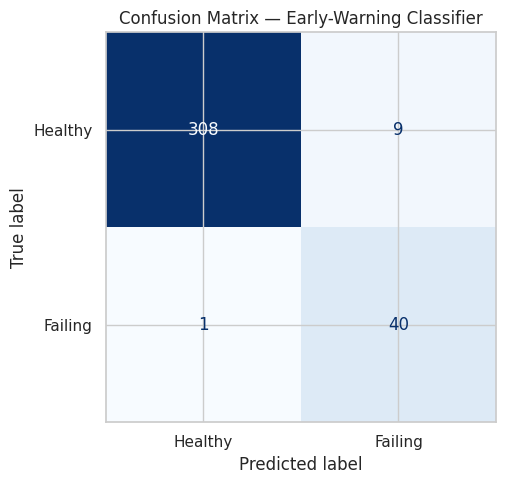

True positives (correctly caught failures):  40
False negatives (missed failures):            1
False positives (false alarms):                9
True negatives (correctly left alone):         308

Sensitivity / Recall (catch rate for real failures): 0.976
Specificity (correctly cleared healthy pumps):        0.972
Precision (of every alarm raised, % that were real):  0.816


In [15]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5.5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy', 'Failing'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Early-Warning Classifier')
fig.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0

print(f"True positives (correctly caught failures):  {tp}")
print(f"False negatives (missed failures):            {fn}")
print(f"False positives (false alarms):                {fp}")
print(f"True negatives (correctly left alone):         {tn}")
print()
print(f"Sensitivity / Recall (catch rate for real failures): {sensitivity:.3f}")
print(f"Specificity (correctly cleared healthy pumps):        {specificity:.3f}")
print(f"Precision (of every alarm raised, % that were real):  {precision:.3f}")

### 3.3 Business implication

- **Sensitivity (recall) is the number that matters most here.** Missing
  a real failure (a false negative) means an unplanned outage that costs
  many hours of lost production — exactly the problem Week 5 quantified.
  A high sensitivity means the model catches most real failures before
  they happen.
- **Precision matters for a different reason: crew time.** Every false
  positive sends a maintenance crew to inspect a pump that turns out to be
  fine. Too many false alarms and the team starts ignoring the alerts
  altogether — a well-known failure mode for alert systems in general.
- With only 4 pumps and 19 failure events over a year, this is a small
  dataset by machine-learning standards — the model's numbers above should
  be read as a **proof of concept that the engineered features carry real
  signal**, not as a production-ready reliability figure. The clear
  separation in the degradation charts in Part 2 is, if anything, more
  convincing than the classification metrics alone: vibration, temperature,
  and pressure genuinely do move together and predictably in the days
  before a real ESP failure in this fleet.
- **Recommended next step**, laid out in more detail in the accompanying
  technical brief: expand telemetry collection to the rest of the ESP
  fleet, gather more failure events over time, and revisit the
  sensitivity/false-positive tradeoff with the maintenance team once
  there's enough data to tune the decision threshold deliberately rather
  than relying on the default.